# Convolutional Neural Networks

## Image classification with a convolutional neural network
This notebook guide you through the building and the use of a convolutional neural network (CNN) for solving the Fashion-MNIST problem we used in the previous notebook. 

To begin with, let's load and prepare the data as we did in the previous notebook:

NameError: name 'X_train' is not defined

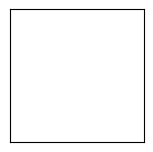

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

fashion_mnist = tf.keras.datasets.fashion_mnist
...
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

## Building the CNN model

The CNN architecture we propose to use is composed of two convolutional layers and two dense layers for classification. 

The convolutional layers will apply 32 filters to the input image, followed by a max-pooling layer, another layer of 64 filters and another max-pooling layer. 
One can add a dropout layer (https://keras.io/api/layers/regularization_layers/dropout/) after any layer to prevent overfitting. It randomly nullifies a portions of the neurons of the layer, and allow thus to force the model to learn multiple representations of the same data.

The dense layer will have 128 neurons and a ReLU activation function. The output layer will have 10 neurons, one for each class, and a softmax activation function. 

In [2]:
model = tf.keras.models.Sequential()
input_shape = (28, 28, 1)  # Fashion-MNIST images are 28x28 pixels with 1 color channel (grayscale)

# 1. Conv. layers
# Input layer
model.add(tf.keras.Input(shape=input_shape))
# Conv2D layer with 32 filters of size 3x3, ReLU activation
model.add(tf.keras.layers.Conv2D(...)) 
# Maxpooling will reduce the number of parameters to learn, which shortens training time.
model.add(tf.keras.layers.MaxPooling2D(...))
...

# 2. Dense layer
# Output from previous layer is a 3D tensor, that must be flattened to a 1D 
# vector before being fed to the Dense Layers.
model.add(tf.keras.layers.Flatten())
...

# 3. Build the model
model.compile(...)

TypeError: Conv2D.__init__() missing 1 required positional argument: 'kernel_size'

## Visualizing the model
It is usually important to check the main characteristics of the model before training it. The `summary` method of the model object provides a summary of the model's structure and the `plot_model` function from the `keras.utils` module can be used to visualize the model's structure.

In [3]:
model.summary()
tf.keras.utils.plot_model(model, to_file='model.png', show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

ValueError: This model has not yet been built. Build the model first by calling `build()` or by calling the model on a batch of data.

## Training the model

The model is trained using the `fit` method of the model object. For training this CNN, use a batch size of 256 and train the model for 20 epochs. The `validation_data` parameter can be used to provide a validation set to monitor the model's performance during training or alternatively, the `validation_split` parameter can be used to specify the percentage of the training data to use as a validation set. Finally, don't forget to save the best model using the `ModelCheckpoint` callback as done in the previous notebook.

In [4]:
import numpy as np

# Add an empty color dimension as the Convolutional net is expecting this
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

# Train the CNN on the training data
...

NameError: name 'X_train' is not defined

## Analysis of the result
As usual, the first thing to do is to plot the loss and accuracy of the model during training. This can be done by plotting the history of the training stored in the `history` attribute of the object returned by the `fit` method. 

TypeError: float() argument must be a string or a real number, not 'ellipsis'

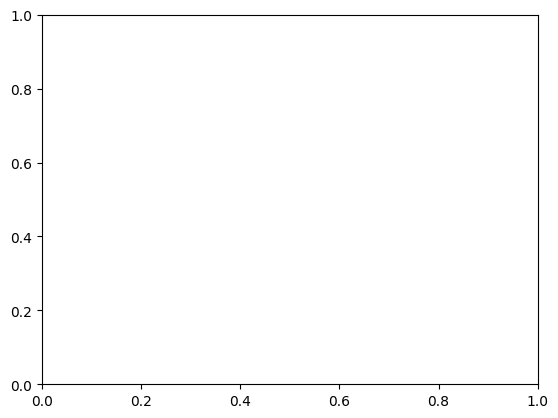

In [5]:
plt.plot(...) 
plt.plot(...) 
plt.title('Model loss') 
plt.ylabel('Loss') 
plt.xlabel('Epoch') 
plt.legend(['Train', 'Validation'], loc='upper right') 
plt.show()

best_epoch = ...
best_val_loss = ...
print(f"The best model have been obtained at epoch {best_epoch} with a loss equal to {best_val_loss}")

<span style="color:blue">What is your analysis of these curves? What can you conclude from them?</span>

## Evaluate the performances
We propose here to compare the performance obtained by the CNN with the one obtained by the DNN learnt on the same problem in the previous notebook. To do so, load the DNN model obtained in the previous notebook and evaluate it on the test set (remember this model has been saved in `.keras` file). Then, evaluate the CNN model on the test set and compare the results.

In [6]:
dnn_model = tf.keras.models.load_model(...)
...
print('DNN - Test loss:', test_loss)
print('DNN - Test accuracy:', test_acc)

cnn_model = tf.keras.models.load_model(...)
...
print('CNN - Test loss:', test_loss)
print('CNN - Test accuracy:', test_acc)

TypeError: stat: path should be string, bytes, os.PathLike or integer, not ellipsis

<span style="color:blue">What is your conclusion?</span>

## Visualizing the predictions
Finally, let's visualize the predictions of the CNN model on the test set. To do so, copy and paste the code from the previous notebook that plot X random images of the test set, their predicted labels, and the true labels.

In [7]:
...

# Plot X random test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
...
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>